- [![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/c4dynamics/c4dynamics/blob/main/docs/source/programs/ardupilot_sim/ardupilot_fig8.ipynb) ← Click to open in Google Colab
- To download this notebook, click the download icon in the toolbar above and select the .ipynb format.
- For any questions or comments, please open an issue on the [c4dynamics issues page](https://github.com/c4dynamics/c4dynamics/issues).

# ArduPilot Simulator — Figure-8 Tracking with the ArduCopter Control Stack

*Fly your algorithm against ArduPilot's own controllers before you fly it for real.*

<div style="margin-top: 30px;"></div>

This notebook flies a *figure-8* ($\infty$) by **ArduCopter** — a Python port of the position, attitude and rate controllers and the motor mixer of the [ArduPilot](https://ardupilot.org/) firmware, version **Copter-4.7.1**.

The main loop generates the reference trajectory and talks to the autopilot the way a MAVLink script does — set `GUIDED`, arm, take off, stream position targets, land. The autopilot reads its sensors and drives the motors.

> *Companion computer* is ArduPilot's term for the onboard computer that runs the mission and commands the autopilot over MAVLink — in aerospace terms, the *mission computer*. The flight controller keeps the vehicle stable and on target; the companion computer decides where the target is.

For a hand-written 3-loop cascade PID flies a *figure-8* ($\infty$) see [Quadcopter Cascade-PID example](https://c4dynamics.github.io/c4dynamics/programs/pid_cascade/quadcopter_pid.html), 

## Goal

1. Build a closed loop of *companion computer* → *ArduPilot* → *vehicle* in which ArduPilot runs its real control law, with its real parameter names and defaults.
2. Fly the *figure-8* in `GUIDED` mode and evaluate how well the stock ArduCopter tuning tracks it on a 3DR Iris airframe.
3. Use the simulator the way it is meant to be used: change an ArduPilot parameter and see the effect before going to the field.

## Table of Contents

1. Introduction
2. Dynamics
3. Sensors
4. Main Loop
5. Results

---
## 1. Introduction

### 1.1. Setup

In [1]:
import sys
# On Google Colab, install c4dynamics -- it ships this example's ArduPilot port too.
if 'google.colab' in sys.modules:
    !pip install -q c4dynamics

import numpy as np
import c4dynamics as c4d
from matplotlib import pyplot as plt

from c4dynamics.utils.use_cases import ardupilot

- A supporting file for this example is the flight-controller port, [c4dynamics.utils.use_cases.ardupilot](https://github.com/c4dynamics/c4dynamics/blob/main/c4dynamics/utils/use_cases/ardupilot.py) — the "firmware" of this simulation.
- Everything else — the vehicle dynamics, the sensors, the main loop, the plots — is written in this notebook.

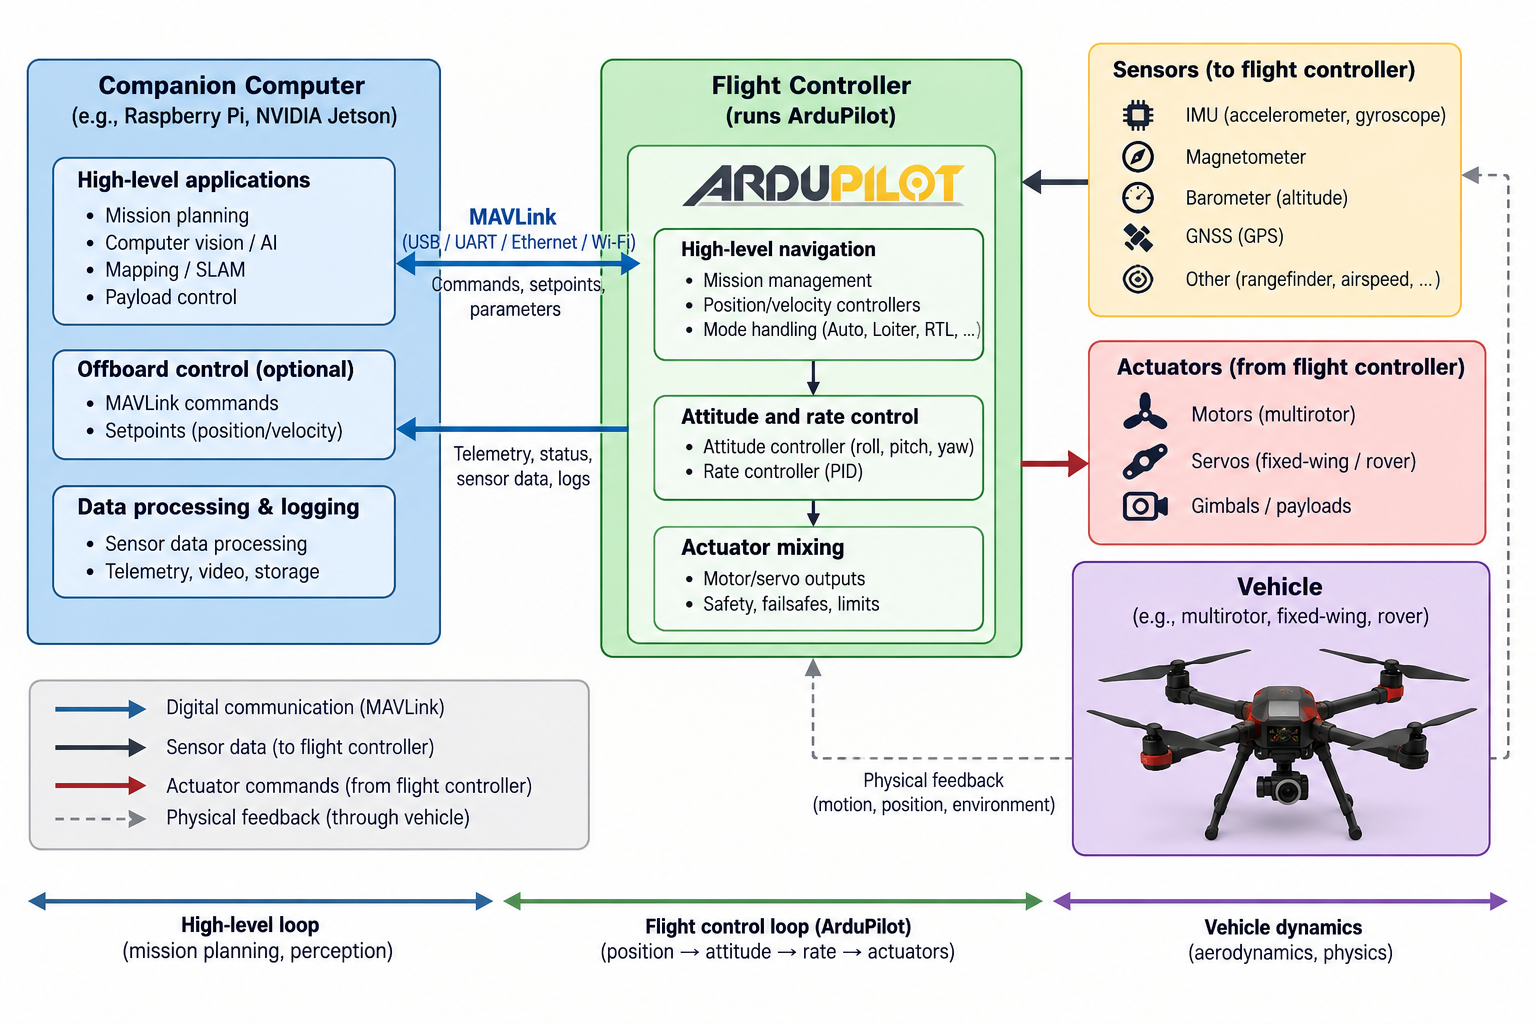

### 1.2. ArduPilot in the Loop

On a real drone, three computers share the work:

```
 companion computer (50 Hz)        flight controller (400 Hz)          vehicle
 --------------------------        --------------------------          -------
 mission / reference      MAVLink  ArduCopter, GUIDED mode      PWM    motors
 arm, takeoff, setpoints ───────▶  position -> attitude      ───────▶  rigid body
 land                      (NED)   -> rate -> motor mixer
                                         ▲                               │
                                         └──────── IMU, navigation ──────┘
```

This simulation keeps exactly this split, and each block is a separate object in the main loop:

| Block | In this notebook | Rate |
|---|---|---|
| Companion computer | the main loop: figure-8 reference, MAVLink-like calls | $50\,Hz$ |
| Flight controller | `ardupilot.ArduCopter` | $400\,Hz$ |
| Vehicle | `QuadPlant`: [rigidbody](https://c4dynamics.github.io/c4dynamics/api/states.lib.rigidbody.html) dynamics, motors, sensors | $400\,Hz$ |

The interface between the blocks is the real interface: the companion sends position / velocity / acceleration targets in $NED$ (`SET_POSITION_TARGET_LOCAL_NED`), the flight controller reads an $IMU$ sample and a navigation solution and returns four $PWM$ values.

### 1.3. The ArduCopter Port

The flight controller is a line-by-line Python port of the ArduPilot libraries that fly a multicopter in `GUIDED` mode. Function names and parameter names follow the C++ source, so the two can be read side by side.

| ArduPilot library | Role | Main parameters |
|---|---|---|
| `AC_PosControl` | position (sqrt-$P$) → velocity ($PID$) → acceleration; vertical: acceleration ($PID$) → throttle | `PSC_*`, `WP_SPD*`, `WP_ACC*` |
| `AC_AttitudeControl_Multi` | thrust vector + heading → quaternion attitude error → body-rate target; body-rate $PID$s | `ATC_*` |
| `AP_MotorsMatrix` | roll / pitch / yaw / throttle → four motor outputs (quad $X$), thrust linearisation, $PWM$ | `MOT_*` |
| `AC_PID`, `AP_Math` | the $PID$ family, square-root controller, jerk-limited kinematic shaping | |

The fast loop runs in the same order as `ArduCopter/Copter.cpp`:

```
read IMU -> rate controller -> motors output -> read AHRS -> flight mode (position + attitude control)
```

so the rate PIDs act on the body-rate target computed one tick earlier, as on the real vehicle.

**What is not ported yet.** State estimation is the main simplification: instead of running $EKF3$, the $AHRS$ takes the navigation solution from the simulator (Section 3). Spool-up ramps, notch filters, battery compensation and terrain following are also left out. Takeoff and landing are simplified versions of ArduCopter's.

The flight controller is created with its default parameters. Any ArduPilot parameter can be overridden by name, exactly as in a `.param` file:

In [2]:
copter = ardupilot.ArduCopter()

print(f"{len(copter.params)} parameters, e.g.:")
for name in ['SCHED_LOOP_RATE', 'ATC_ANG_PIT_P', 'ATC_RAT_PIT_P', 'ATC_RAT_PIT_I', 'ATC_RAT_PIT_D',
             'PSC_NE_POS_P', 'PSC_NE_VEL_P', 'PSC_D_ACC_P', 'MOT_THST_EXPO', 'MOT_THST_HOVER']:
    print(f"  {name:16s} = {copter.params[name]}")

87 parameters, e.g.:
  SCHED_LOOP_RATE  = 400
  ATC_ANG_PIT_P    = 4.5
  ATC_RAT_PIT_P    = 0.135
  ATC_RAT_PIT_I    = 0.135
  ATC_RAT_PIT_D    = 0.0036
  PSC_NE_POS_P     = 1.0
  PSC_NE_VEL_P     = 2.0
  PSC_D_ACC_P      = 0.05
  MOT_THST_EXPO    = 0.65
  MOT_THST_HOVER   = 0.35


The parameters of this run. Edit the dictionary to try your own values (an unknown name raises an error, so typos do not pass silently):

In [3]:
ardupilot_params = {
    # e.g. 'ATC_RAT_PIT_P': 0.2,
}

---
## 2. Dynamics

### 2.1. Frames

This example uses ArduPilot's conventions throughout the vehicle and the flight controller:

- Earth frame $NED$: $x$ north, $y$ east, $z$ down.
- Body frame $FRD$: $x$ forward, $y$ right, $z$ down.
- Euler angles $3$-$2$-$1$: yaw $\psi$ → pitch $\theta$ → roll $\varphi$.

The companion computer keeps the figure-8 in $ENU$ ($x$ east, $y$ north, $z$ up), as in the Cascade-PID example, and converts to $NED$ when it sends a target (Section 4) — the same place MAVROS or a companion script does it.

### 2.2. Rigid Body

The vehicle is a [rigidbody](https://c4dynamics.github.io/c4dynamics/api/states.lib.rigidbody.html) with the 12-state vector

$$
\mathbf{x} = \begin{bmatrix} x & y & z & v_x & v_y & v_z & \varphi & \theta & \psi & p & q & r \end{bmatrix}^T
$$

position and velocity in $NED$ [$m$, $m/s$], Euler angles [$rad$] and $FRD$ body rates [$rad/s$].

**Translational dynamics.** Thrust $T$ acts along $-z$ of the body, linear drag opposes the body velocity $\mathbf v_b = [BI]\,\mathbf v$:

$$
\mathbf F_b = \begin{bmatrix} 0 \\ 0 \\ -T \end{bmatrix} - \begin{bmatrix} A_x u \\ A_y v \\ A_z w \end{bmatrix},
\qquad
\dot{\mathbf v} = \frac{[BI]^T \mathbf F_b}{m} + \begin{bmatrix} 0 \\ 0 \\ g \end{bmatrix}
$$

where $[BI]$ is the body-from-inertial $DCM$ ([c4d.rotmat.dcm321](https://c4dynamics.github.io/c4dynamics/api/rotmat.dcm321.html)).

**Rotational dynamics.** Euler's equations with rotor moments $\boldsymbol\tau$ and rotational damping $A_r$:

$$
I \dot{\boldsymbol\omega} = \boldsymbol\tau - A_r \boldsymbol\omega - \boldsymbol\omega \times I \boldsymbol\omega,
\qquad \boldsymbol\omega = [p, q, r]^T
$$

and the Euler-angle kinematics

$$
\dot\varphi = p + (q \sin\varphi + r \cos\varphi)\tan\theta, \qquad
\dot\theta = q \cos\varphi - r \sin\varphi, \qquad
\dot\psi = \frac{q \sin\varphi + r \cos\varphi}{\cos\theta}
$$

**Ground.** The vehicle cannot go below $z = 0$: while it rests on the ground, the ground carries its weight.

### 2.3. Motors

ArduPilot numbers the motors of a quad $X$ as follows (top view):

```
      3 (CW)     1 (CCW)        x forward
           \     /
            \   /
            /   \
           /     \
      2 (CCW)    4 (CW)         y right
```

Each rotor $i$ at body position $(x_i, y_i)$ produces thrust $F_i = k_T \Omega_i^2$ and reaction torque $k_Q \Omega_i^2$, with spin direction $d_i = +1$ for $CCW$, $-1$ for $CW$:

$$
T = \sum F_i, \qquad
\boldsymbol\tau = \begin{bmatrix} -\sum y_i F_i \\ \sum x_i F_i \\ \sum d_i k_Q \Omega_i^2 \end{bmatrix}
$$

**ESC and motor.** The flight controller outputs $PWM$. The ESC maps it to a normalized command $u = (PWM - 1000)/1000$, the motor starts producing thrust above $u_{min}$ (spin-min) and saturates at $u_{max}$ (spin-max). Within that range the thrust follows the quadratic curve ArduPilot assumes (`MOT_THST_EXPO`, $a = 0.65$):

$$
e = \frac{u - u_{min}}{u_{max} - u_{min}}, \qquad
\frac{F}{F_{max}} = (1-a)\,e + a\,e^2
$$

The rotor speed follows its command through a first-order lag, faster spinning up than down.

### 2.4. Vehicle Parameters

The airframe is the 3DR Iris, with mass, inertia and rotor data from the Gazebo `iris.sdf` model (see [iris_quadcopter.py](https://github.com/c4dynamics/c4dynamics/blob/main/c4dynamics/utils/use_cases/iris_quadcopter.py)). Rotor positions are given in $FRD$, in ArduPilot's motor order:

In [4]:
iris = {
    'm'        : 1.5,                         # mass [kg]
    'g'        : 9.80665,                     # gravity [m/s^2]
    'I'        : np.diag([0.0347563, 0.0458929, 0.0977]),  # inertia [kg.m^2]
    'kT'       : 8.5485e-6,                   # thrust coefficient [N/(rad/s)^2]
    'kQ'       : 1.6e-7,                      # torque coefficient [N.m/(rad/s)^2]
    'omega_max': 838.0,                       # max rotor speed [rad/s]
    'tau_up'   : 0.0125,                      # motor spin-up time constant [s]
    'tau_down' : 0.025,                       # motor spin-down time constant [s]
    'rotor_pos': np.array([[ 0.13,  0.22],    # motor 1  front-right  [m] (x fwd, y right)
                           [-0.13, -0.20],    # motor 2  rear-left
                           [ 0.13, -0.22],    # motor 3  front-left
                           [-0.13,  0.20]]),  # motor 4  rear-right
    'rotor_dir': np.array([1, 1, -1, -1]),    # +1 CCW, -1 CW
    'thrust_expo': 0.65,                      # thrust curve
    'spin_min' : 0.15,                        # ESC command where thrust starts
    'spin_max' : 0.95,                        # ESC command where thrust saturates
    'A'        : np.array([0.30, 0.30, 0.25]),# linear drag [N/(m/s)]
    'Ar'       : 0.002,                       # rotational damping [N.m/(rad/s)]
}

F_max = iris['kT'] * iris['omega_max']**2
print(f"max thrust per motor {F_max:.2f} N | thrust-to-weight {4 * F_max / (iris['m'] * iris['g']):.2f} "
      f"| hover thrust fraction {iris['m'] * iris['g'] / (4 * F_max):.3f}")

max thrust per motor 6.00 N | thrust-to-weight 1.63 | hover thrust fraction 0.613


The Iris hovers at about $61\%$ of its maximum thrust — a heavy, low-margin vehicle. ArduCopter's default `MOT_THST_HOVER` is $0.35$; the autopilot learns the true value in flight (Section 5).

### 2.5. The Vehicle Model

`QuadPlant` holds the [rigidbody](https://c4dynamics.github.io/c4dynamics/api/states.lib.rigidbody.html) and the four rotor speeds. `step` advances it by one time step under constant $PWM$: the motors follow their commands, and the rigid body is integrated with a $4^{th}$-order Runge-Kutta step.

In [5]:
class QuadPlant:

    def __init__(self, params, yaw0=0.0):
        self.c = params
        self.body = c4d.rigidbody(psi=yaw0)     # NED / FRD state, at rest on the ground
        self.omega = np.zeros(4)                # rotor speeds [rad/s]
        self.specific_force = np.array([0.0, 0.0, -params['g']])   # what the accelerometer feels

    # -- motors ------------------------------------------------------------
    def motors(self, pwm, dt):
        c = self.c
        u = (np.asarray(pwm) - 1000.0) / 1000.0
        e = np.clip((u - c['spin_min']) / (c['spin_max'] - c['spin_min']), 0.0, 1.0)
        a = c['thrust_expo']
        omega_cmd = c['omega_max'] * np.sqrt((1 - a) * e + a * e**2)
        tau = np.where(omega_cmd > self.omega, c['tau_up'], c['tau_down'])
        self.omega = omega_cmd + (self.omega - omega_cmd) * np.exp(-dt / tau)

        F = c['kT'] * self.omega**2
        T = F.sum()
        tau_b = np.array([-(c['rotor_pos'][:, 1] * F).sum(),
                          (c['rotor_pos'][:, 0] * F).sum(),
                          (c['rotor_dir'] * c['kQ'] * self.omega**2).sum()])
        return T, tau_b

    # -- rigid body --------------------------------------------------------
    def derivatives(self, X, T, tau_b):
        c = self.c
        phi, theta, psi = X[6:9]
        w = X[9:12]
        BI = c4d.rotmat.dcm321(phi, theta, psi)       # body from NED

        F_b = np.array([0.0, 0.0, -T]) - c['A'] * (BI @ X[3:6])
        dv = BI.T @ F_b / c['m'] + np.array([0.0, 0.0, c['g']])
        dw = np.linalg.solve(c['I'], tau_b - c['Ar'] * w - np.cross(w, c['I'] @ w))

        p, q, r = w
        deuler = [p + (q * np.sin(phi) + r * np.cos(phi)) * np.tan(theta),
                  q * np.cos(phi) - r * np.sin(phi),
                  (q * np.sin(phi) + r * np.cos(phi)) / np.cos(theta)]
        return np.concatenate([X[3:6], dv, deuler, dw]), F_b / c['m']

    def step(self, pwm, dt):
        T, tau_b = self.motors(pwm, dt)
        X = self.body.X
        k1, f = self.derivatives(X, T, tau_b)
        k2, _ = self.derivatives(X + dt / 2 * k1, T, tau_b)
        k3, _ = self.derivatives(X + dt / 2 * k2, T, tau_b)
        k4, _ = self.derivatives(X + dt * k3, T, tau_b)
        X = X + dt / 6 * (k1 + 2 * k2 + 2 * k3 + k4)
        self.specific_force = f

        if X[2] >= 0 and X[5] >= 0:                   # on the ground
            X[[2, 3, 4, 5, 6, 7, 9, 10, 11]] = 0.0
            self.specific_force = c4d.rotmat.dcm321(psi=X[8]) @ [0.0, 0.0, -self.c['g']]
        self.body.X = X

---
## 3. Sensors

ArduCopter reads two things from the vehicle every fast-loop tick:

**$IMU$ — gyroscope and accelerometer.** The gyroscope measures the body rates $[p, q, r]$. The accelerometer measures the *specific force* — the non-gravitational acceleration in the body frame, $\mathbf f = \mathbf F_b / m$. At rest it reads $-g$ on $z$ (the ground pushes up); in hover it reads $\approx -g$ on $z$ (the thrust pushes up).

$$
\mathbf z_{gyro} = \boldsymbol\omega + \mathbf n_g, \qquad \mathbf z_{acc} = \mathbf f + \mathbf n_a
$$

Inside the autopilot both pass through the 2-pole low-pass filters `INS_GYRO_FILTER` and `INS_ACCEL_FILTER` ($20\,Hz$) before the controllers use them.

**Navigation solution.** On a real vehicle $EKF3$ fuses the $IMU$ with $GPS$, compass and barometer into attitude, position and velocity. This draft does not port $EKF3$ yet: the navigation solution is the true state, with optional noise. This is the simulation's main simplification, and the next step of the use case.

| Sensor | Measures | Default noise ($1\sigma$) | Rate |
|---|---|---|---|
| Gyroscope | $p, q, r$ | $0.005\,rad/s$ | $400\,Hz$ |
| Accelerometer | $f_x, f_y, f_z$ | $0.05\,m/s^2$ | $400\,Hz$ |
| Navigation (EKF stand-in) | $\varphi, \theta, \psi$, $NED$ position and velocity | $0$ | $400\,Hz$ |

In [6]:
sensors = {
    'gyro_std' : 0.005,   # [rad/s]
    'accel_std': 0.05,    # [m/s^2]
    'att_std'  : 0.0,     # [rad]
    'pos_std'  : 0.0,     # [m]
    'vel_std'  : 0.0,     # [m/s]
}


def read_imu(plant):
    return {'gyro' : plant.body.X[9:12] + sensors['gyro_std'] * np.random.randn(3),
            'accel': plant.specific_force + sensors['accel_std'] * np.random.randn(3)}


def read_nav(plant):
    X = plant.body.X
    return {'euler'  : X[6:9] + sensors['att_std'] * np.random.randn(3),
            'pos_ned': X[0:3] + sensors['pos_std'] * np.random.randn(3),
            'vel_ned': X[3:6] + sensors['vel_std'] * np.random.randn(3)}

---
## 4. Main Loop

### 4.1. The Reference

The reference is the **Lissajous figure-8** of the Cascade-PID example, at a fixed altitude, in $ENU$:

$$
x_{ref} = A \sin(\omega \tau), \qquad y_{ref} = B \sin(2 \omega \tau), \qquad z_{ref} = h
$$

Unlike the Cascade-PID example, the companion sends ArduPilot the velocity and acceleration as well — its position controller uses them as feedforward:

$$
\dot x_{ref} = A \omega \cos(\omega\tau), \quad \dot y_{ref} = 2B\omega\cos(2\omega\tau), \quad
\ddot x_{ref} = -A\omega^2\sin(\omega\tau), \quad \ddot y_{ref} = -4B\omega^2\sin(2\omega\tau)
$$

After one loop, a smooth return brings the vehicle back over the origin and down to $0.3\,m$.

In [7]:
trajectory = {
    'A'         : 4.0,    # figure-8 east amplitude [m]
    'B'         : 2.0,    # figure-8 north amplitude [m]
    'omega'     : 0.1,    # angular frequency [rad/s]  (one loop ~ 62.8 s)
    'h'         : 5.0,    # flight altitude [m]
    'yaw'       : 0.0,    # heading, ENU [rad] (0 = facing east)
    't_hold'    : 2.0,    # hover after takeoff [s]
    't_return'  : 8.0,    # return to the origin and descend to 0.3 m [s]
    'land_speed': 0.5,    # final descent rate [m/s]
}


def figure8(tau, tr):
    A, B, w, h = tr['A'], tr['B'], tr['omega'], tr['h']
    pos = np.array([A * np.sin(w * tau), B * np.sin(2 * w * tau), h])
    vel = np.array([A * w * np.cos(w * tau), 2 * B * w * np.cos(2 * w * tau), 0.0])
    acc = np.array([-A * w**2 * np.sin(w * tau), -4 * B * w**2 * np.sin(2 * w * tau), 0.0])
    return pos, vel, acc


def go_home(tau, p_start, tr):
    s = np.clip(tau / tr['t_return'], 0, 1)
    p_end = np.array([0.0, 0.0, 0.3])
    pos = p_start + (p_end - p_start) * (3 * s**2 - 2 * s**3)
    vel = (p_end - p_start) * (6 * s - 6 * s**2) / tr['t_return']
    return pos, vel, np.zeros(3)

### 4.2. Frames at the MAVLink Boundary

$ENU$ and $NED$ swap $x$ and $y$ and flip $z$; a heading measured from east ($ENU$) becomes a heading measured from north ($NED$):

In [8]:
def enu2ned(v):
    return np.array([v[1], v[0], -v[2]])

ned2enu = enu2ned       # the same swap both ways


def yaw_enu2ned(yaw):
    return np.pi / 2 - yaw

### 4.3. The Mission

The companion computer runs the mission as a sequence of phases, each one the MAVLink step a real script would take:

| Phase | Companion action | ArduPilot |
|---|---|---|
| preflight | `set_mode('GUIDED')`, `arm()` | motors at `MOT_SPIN_ARM` |
| takeoff | `takeoff(h)` (`MAV_CMD_NAV_TAKEOFF`) | jerk-limited climb at `WP_SPD_UP`, `WP_ACC_Z` |
| hold | position target at the origin | position hold |
| figure8 | position + velocity + acceleration targets at $50\,Hz$ | `GUIDED` pos-vel-accel control |
| return | smooth return to the origin, down to $0.3\,m$ | |
| land | descend at $0.5\,m/s$ through the ground | land detector → `land_complete` |
| disarmed | `disarm()` | motors stopped |

### 4.4. The Loop

Every $2.5\,ms$ tick, three things happen in order: the **companion** (every $8^{th}$ tick, i.e. $50\,Hz$) updates the mission and sends targets, the **flight controller** reads the sensors and returns $PWM$, and the **vehicle** advances under that $PWM$.

In [9]:
def run(ardupilot_params, trajectory, t_max=120.0, setpoint_rate=50.0, log_rate=50.0, seed=0, verbose=True):

    np.random.seed(seed)
    tr = trajectory

    copter = ardupilot.ArduCopter(ardupilot_params)
    plant  = QuadPlant(iris, yaw0=yaw_enu2ned(tr['yaw']))
    dt     = copter.dt                                           # 1 / SCHED_LOOP_RATE
    sp_every  = int(round(copter.loop_rate_hz / setpoint_rate))
    log_every = int(round(copter.loop_rate_hz / log_rate))

    body = plant.body
    body.pwm1 = body.pwm2 = body.pwm3 = body.pwm4 = 0.0
    body.hover = copter.motors.get_throttle_hover()
    ref = c4d.state(x=0.0, y=0.0, z=0.0)                         # commanded reference, ENU

    yaw = yaw_enu2ned(tr['yaw'])
    t_fig8 = 2 * np.pi / tr['omega']
    phase, t_phase, events = 'preflight', 0.0, {}
    p_ref = np.zeros(3)

    copter.set_mode('GUIDED')
    copter.arm()

    for k in range(int(t_max / dt)):
        t = k * dt

        # ── companion computer ────────────────────────────────────────
        if k % sp_every == 0:

            if phase == 'preflight' and t >= 1.0:
                copter.takeoff(tr['h'])
                phase, t_phase = 'takeoff', t

            elif phase == 'takeoff':
                # ArduPilot shapes the climb itself; log its target as the reference
                p_ref = ned2enu(copter.pos_control.get_pos_desired_NED_m())
                if copter.takeoff_complete():
                    phase, t_phase = 'hold', t

            elif phase == 'hold':
                p_ref = np.array([0.0, 0.0, tr['h']])
                copter.set_position_target_local_ned(enu2ned(p_ref), yaw=yaw)
                if t - t_phase >= tr['t_hold']:
                    phase, t_phase = 'figure8', t

            elif phase == 'figure8':
                p_ref, v_ref, a_ref = figure8(min(t - t_phase, t_fig8), tr)
                copter.set_position_target_local_ned(enu2ned(p_ref), enu2ned(v_ref), enu2ned(a_ref), yaw=yaw)
                if t - t_phase >= t_fig8:
                    phase, t_phase, p_exit = 'return', t, p_ref.copy()

            elif phase == 'return':
                p_ref, v_ref, a_ref = go_home(t - t_phase, p_exit, tr)
                copter.set_position_target_local_ned(enu2ned(p_ref), enu2ned(v_ref), enu2ned(a_ref), yaw=yaw)
                if t - t_phase >= tr['t_return']:
                    phase, t_phase = 'land', t

            elif phase == 'land':
                p_ref = np.array([0.0, 0.0, 0.3 - tr['land_speed'] * (t - t_phase)])
                copter.set_position_target_local_ned(enu2ned(p_ref), enu2ned([0, 0, -tr['land_speed']]), yaw=yaw)
                if copter.land_complete:
                    copter.disarm()
                    phase, t_phase = 'disarmed', t

            elif phase == 'disarmed' and t - t_phase >= 1.0:
                break

            if phase not in events:
                events[phase] = t
                if verbose:
                    print(f't = {t:6.2f} s  ->  {phase}')

        # ── flight controller ─────────────────────────────────────────
        pwm = copter.update(t, read_imu(plant), read_nav(plant))

        # ── log ───────────────────────────────────────────────────────
        if k % log_every == 0:
            body.pwm1, body.pwm2, body.pwm3, body.pwm4 = pwm
            body.hover = copter.motors.get_throttle_hover()
            body.store(t)
            body.storeparams(['pwm1', 'pwm2', 'pwm3', 'pwm4', 'hover'], t=t)
            ref.X = p_ref
            ref.store(t)

        # ── vehicle ───────────────────────────────────────────────────
        plant.step(pwm, dt)

    return body, ref, events, copter

Run the mission:

In [10]:
body, ref, events, copter = run(ardupilot_params, trajectory)
print(f"learned MOT_THST_HOVER = {copter.motors.get_throttle_hover():.3f}")

t =   0.00 s  ->  preflight


t =   1.00 s  ->  takeoff


t =   5.56 s  ->  hold


t =   7.56 s  ->  figure8


t =  70.40 s  ->  return


t =  78.40 s  ->  land


t =  80.98 s  ->  disarmed


learned MOT_THST_HOVER = 0.612


---
## 5. Results

The state is stored in $NED$; for comparison with the reference it is converted back to $ENU$:

In [11]:
t   = body.data('x')[0]
pos = ned2enu(np.array([body.data('x')[1], body.data('y')[1], body.data('z')[1]]))
pr  = np.array([ref.data('x')[1], ref.data('y')[1], ref.data('z')[1]])
fig8_phase = (t >= events['figure8']) & (t < events['return'])

### 5.1. Trajectory

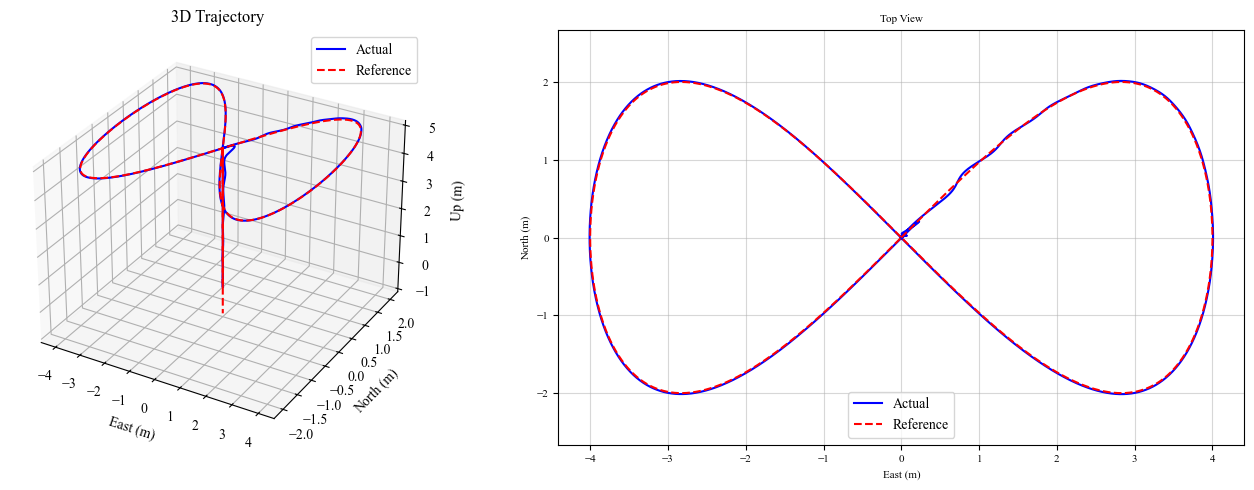

In [12]:
fig = plt.figure(figsize=(14, 5))

ax = fig.add_subplot(1, 2, 1, projection='3d')
ax.plot(*pos, 'b', lw=1.5, label='Actual')
ax.plot(*pr, 'r--', lw=1.5, label='Reference')
ax.set_xlabel('East (m)'); ax.set_ylabel('North (m)'); ax.set_zlabel('Up (m)')
ax.set_title('3D Trajectory'); ax.legend()

ax = fig.add_subplot(1, 2, 2)
ax.plot(pos[0], pos[1], 'b', lw=1.5, label='Actual')
ax.plot(pr[0], pr[1], 'r--', lw=1.5, label='Reference')
c4d.plotdefaults(ax, 'Top View', 'East (m)', 'North (m)')
ax.axis('equal'); ax.legend()
plt.tight_layout()
plt.show()

### 5.2. Tracking

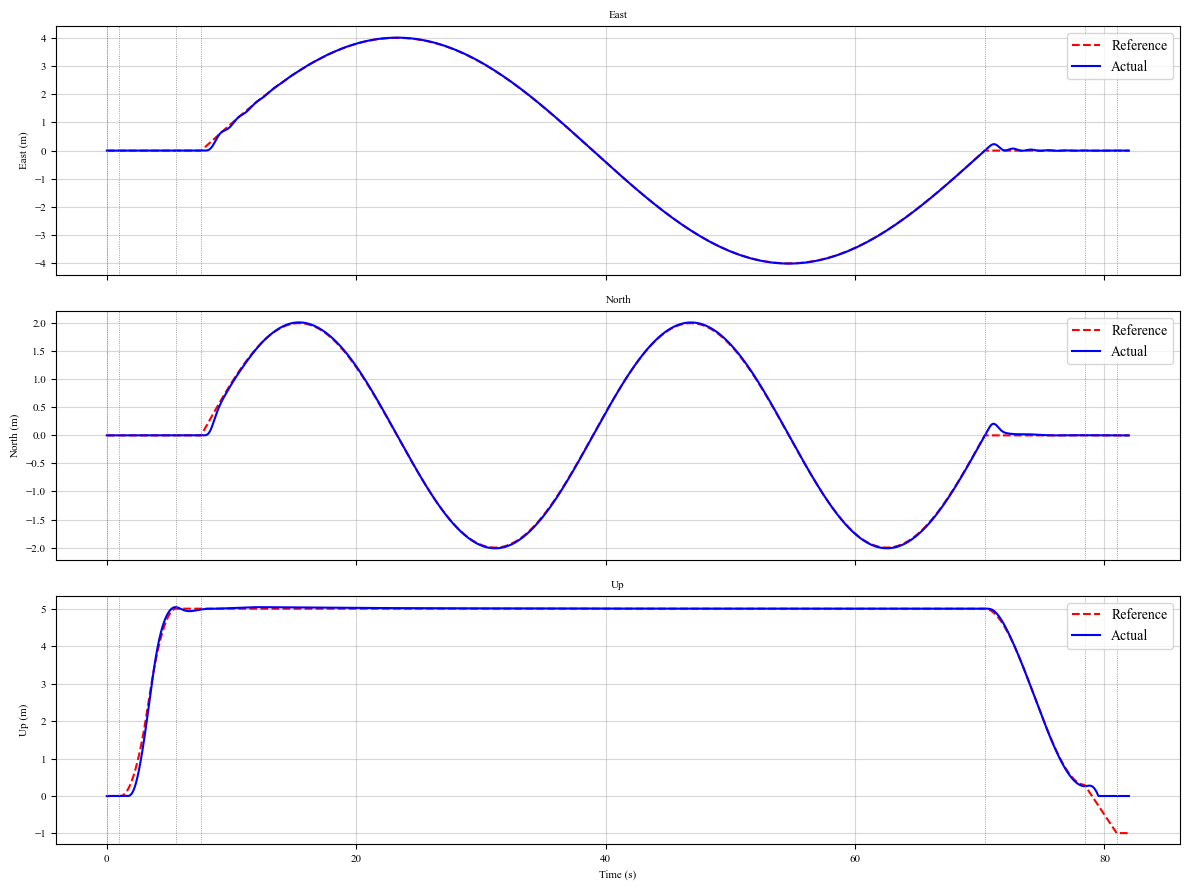

In [13]:
fig, ax = plt.subplots(3, 1, figsize=(12, 9), sharex=True)
for i, name in enumerate(['East', 'North', 'Up']):
    ax[i].plot(t, pr[i], 'r--', lw=1.5, label='Reference')
    ax[i].plot(t, pos[i], 'b', lw=1.5, label='Actual')
    c4d.plotdefaults(ax[i], name, '', f'{name} (m)')
    ax[i].legend(loc='upper right')
ax[2].set_xlabel('Time (s)')
for a in ax:
    for ph, te in events.items():
        a.axvline(te, color='gray', lw=0.6, ls=':')
plt.tight_layout()
plt.show()

The dotted lines mark the mission phases. During the takeoff the reference is ArduPilot's own shaped climb profile (`WP_SPD_UP` $= 2.5\,m/s$, `WP_ACC_Z` $= 1\,m/s^2$). In the final descent the reference goes below the ground on purpose — the vehicle lands, the land detector sees the motors at their lower limit with no vertical motion for $1\,s$, and the companion disarms.

### 5.3. Metrics

Root-mean-square error of the true position against the commanded reference, over the figure-8 phase:

In [14]:
def metrics(t, pos, pr, idx, tr):
    err = pos[:, idx] - pr[:, idx]
    rmse = np.sqrt(np.mean(err**2, axis=1))
    print('=' * 52)
    print('   TRACKING PERFORMANCE  (figure-8 phase)')
    print('=' * 52)
    print(f"  RMSE east  : {rmse[0]:.4f} m   ({rmse[0] / tr['A'] * 100:.2f}% of A)")
    print(f"  RMSE north : {rmse[1]:.4f} m   ({rmse[1] / tr['B'] * 100:.2f}% of B)")
    print(f"  RMSE up    : {rmse[2]:.4f} m   ({rmse[2] / tr['h'] * 100:.2f}% of h)")
    print(f"  max 3D err : {np.max(np.linalg.norm(err, axis=0)):.4f} m")
    print('=' * 52)
    return rmse

rmse = metrics(t, pos, pr, fig8_phase, trajectory)

   TRACKING PERFORMANCE  (figure-8 phase)
  RMSE east  : 0.0250 m   (0.63% of A)
  RMSE north : 0.0248 m   (1.24% of B)
  RMSE up    : 0.0138 m   (0.28% of h)
  max 3D err : 0.3066 m


ArduCopter tracks the figure-8 to a few centimetres. Two things make this possible, both part of ArduPilot's design: the companion sends velocity and acceleration feedforward with every target, and the position controller shapes the commanded path with jerk limits before tracking it, so the vehicle is never asked for more than it can do.

### 5.4. Attitude and Motors

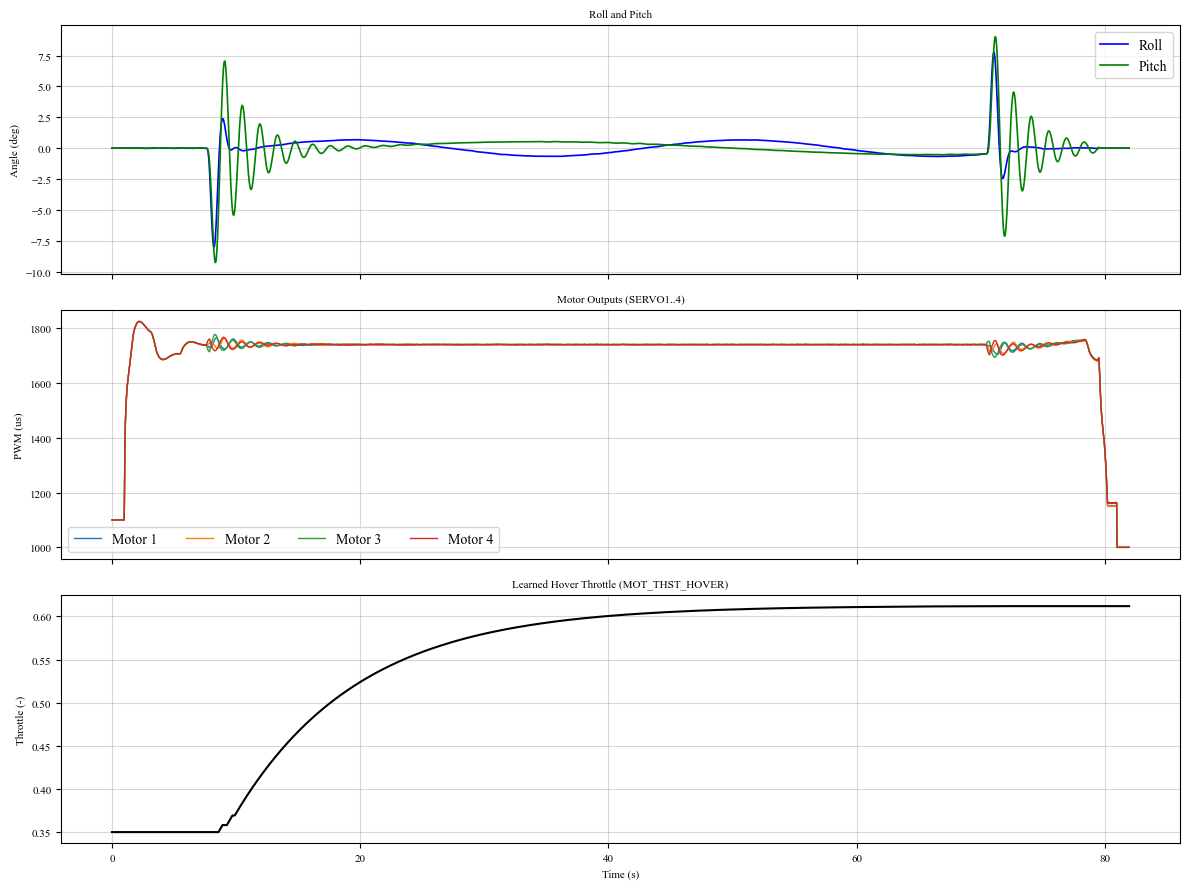

In [15]:
fig, ax = plt.subplots(3, 1, figsize=(12, 9), sharex=True)

ax[0].plot(t, body.data('phi', c4d.r2d)[1], 'b', lw=1.2, label='Roll')
ax[0].plot(t, body.data('theta', c4d.r2d)[1], 'g', lw=1.2, label='Pitch')
c4d.plotdefaults(ax[0], 'Roll and Pitch', '', 'Angle (deg)')
ax[0].legend()

for i in range(1, 5):
    ax[1].plot(*body.data(f'pwm{i}'), lw=1.0, label=f'Motor {i}')
c4d.plotdefaults(ax[1], 'Motor Outputs (SERVO1..4)', '', 'PWM (us)')
ax[1].legend(ncol=4)

ax[2].plot(*body.data('hover'), 'k', lw=1.5)
c4d.plotdefaults(ax[2], 'Learned Hover Throttle (MOT_THST_HOVER)', 'Time (s)', 'Throttle (-)')
plt.tight_layout()
plt.show()

- **Hover throttle.** `MOT_THST_HOVER` starts at ArduCopter's default $0.35$ and converges to $\approx 0.61$ — the Iris's true hover thrust fraction (Section 2.4). Until it converges, the vertical acceleration controller's integrator carries the difference.
- **Pitch ringing.** Where the figure-8 starts and where the return starts, the pitch rings at about $0.7\,Hz$ for several cycles. This is a real finding, not a numerical artifact: the default rate gains are under-tuned for this airframe. The Iris model produces only $\approx 34\,rad/s^2$ of pitch acceleration per unit of rate-controller output, so with the default `ATC_RAT_PIT_P` $= 0.135$ the rate loop is slower than the angle loop above it.

### 5.5. Changing a Parameter

This is what the simulator is for: change a parameter, fly again, compare. Raising the roll and pitch rate gains by a factor of $3$, as a tuning pass (or ArduCopter's `AUTOTUNE`) would do:

In [16]:
tuned = {}
for axis in ['RLL', 'PIT']:
    tuned[f'ATC_RAT_{axis}_P'] = 3 * copter.params[f'ATC_RAT_{axis}_P']
    tuned[f'ATC_RAT_{axis}_I'] = 3 * copter.params[f'ATC_RAT_{axis}_I']
    tuned[f'ATC_RAT_{axis}_D'] = 3 * copter.params[f'ATC_RAT_{axis}_D']
print(tuned)

body2, ref2, events2, _ = run(tuned, trajectory, verbose=False)

{'ATC_RAT_RLL_P': 0.405, 'ATC_RAT_RLL_I': 0.405, 'ATC_RAT_RLL_D': 0.0108, 'ATC_RAT_PIT_P': 0.405, 'ATC_RAT_PIT_I': 0.405, 'ATC_RAT_PIT_D': 0.0108}


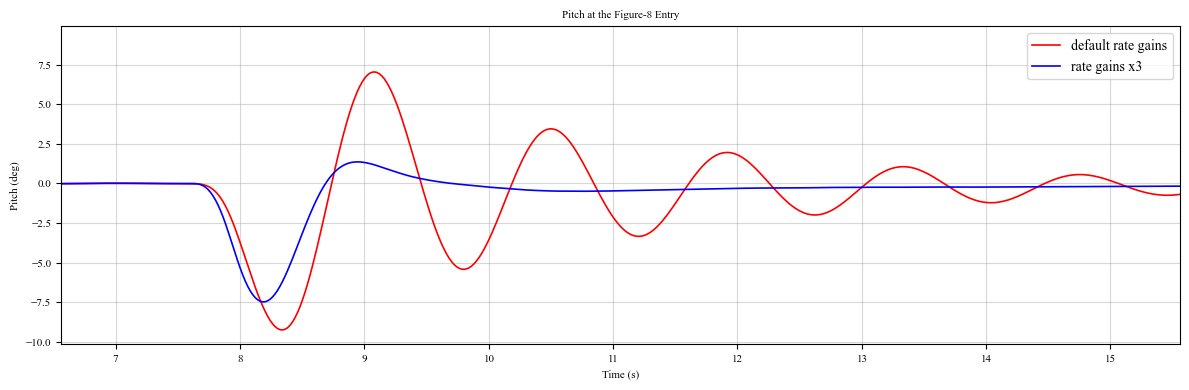

   TRACKING PERFORMANCE  (figure-8 phase)
  RMSE east  : 0.0235 m   (0.59% of A)
  RMSE north : 0.0247 m   (1.24% of B)
  RMSE up    : 0.0140 m   (0.28% of h)
  max 3D err : 0.2843 m


In [17]:
t2 = body2.data('x')[0]

fig, ax = plt.subplots(1, 1, figsize=(12, 4))
ax.plot(t, body.data('theta', c4d.r2d)[1], 'r', lw=1.2, label='default rate gains')
ax.plot(t2, body2.data('theta', c4d.r2d)[1], 'b', lw=1.2, label='rate gains x3')
c4d.plotdefaults(ax, 'Pitch at the Figure-8 Entry', 'Time (s)', 'Pitch (deg)')
ax.set_xlim(events['figure8'] - 1, events['figure8'] + 8)
ax.legend()
plt.tight_layout()
plt.show()

pos2 = ned2enu(np.array([body2.data('x')[1], body2.data('y')[1], body2.data('z')[1]]))
pr2  = np.array([ref2.data('x')[1], ref2.data('y')[1], ref2.data('z')[1]])
rmse2 = metrics(t2, pos2, pr2, (t2 >= events2['figure8']) & (t2 < events2['return']), trajectory)

With the faster rate loop the pitch oscillation is damped within about one cycle instead of ringing for several seconds. The position RMSE barely changes — the position controller hid the problem in the tracking numbers, and only the attitude shows it. The remaining transient comes from the figure-8 entry itself: the reference velocity jumps from hover to $0.57\,m/s$ there.

### 5.6. Summary

- A companion-computer main loop, a Python port of the ArduCopter 4.7.1 control stack, and a c4dynamics rigid-body vehicle make a closed simulation loop with the same interfaces as the real drone: MAVLink-style targets in, sensor samples in, $PWM$ out.
- In `GUIDED` mode, with stock parameters, ArduCopter tracks the figure-8 to a few centimetres, learns the hover throttle in flight, detects the landing and disarms.
- On the Iris model, the stock rate gains are slow, and the pitch rings. This is exactly the kind of finding the simulator is for. Change the parameter here first, then on the vehicle.

**Next steps.** Port $EKF3$ so the autopilot flies on fused $GPS$ / $IMU$ / compass / barometer measurements instead of the true state. Then add ArduCopter's `LAND` and `AUTO` modes, and a real MAVLink interface so an unmodified companion script can drive the simulation.